# Lab 1, Core A: Least squares, conditioning, and $QR$
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>
### <div align="right"> adapted from a 2022 assignment by Ostap Dyhdalovych and Volodymyr Kuchynskyi </div>

## Completed by:
*   Yulian Melnychuk
*   Artem Serbin

### What this core is about

Fitting a model to data is a least squares problem, and you have seen the formula. This
notebook is about the gap between the formula and an algorithm: **the same mathematics,
implemented two ways, stops agreeing** once the problem is hard enough, and one of the two
ways is wrong long before it looks wrong.

You will fit a trend-plus-seasonality model to 166 years of monthly temperature readings,
raise the complexity of the model until your two solvers disagree, and find out which one
to believe and why.

### Marking

This is **Core A** of Lab 1. The lab is worth 6 points: 2 for this core, 2 for Core B
(the DFT), 1 for the code, and up to 1 for extensions. Core marks are awarded at the
**oral defence**, not from the notebook alone, so a correct result you cannot explain is
worth less than a partial result you understand. Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of this one, Extension 3 at the end of Core B. Attempt at most one; a second earns nothing.

Questions marked *harder &mdash; not required* go beyond the course material. They earn no
extra points, are marked generously, and are there to be discussed at the defence.

### Ground rules

* Sections 1-4: implement the linear algebra yourself with basic `numpy`. You may use
  `np.linalg.qr`, `np.linalg.solve`, `np.linalg.cond` and `np.linalg.norm`.
* Always write `np.linalg.qr(A, mode="reduced")` with the mode given **explicitly**.
  The default has not been stable across numpy versions, and `mode="complete"` returns
  an $m \times m$ matrix $Q$ that does not fit the formulas used here.
* **`np.linalg.inv` is forbidden throughout.** If you find yourself wanting it, that is
  the notebook working as intended &mdash; see Question 1.1.
* `np.linalg.lstsq` is allowed **only** where explicitly asked for, as a reference answer.
* Where a cell asks you to *predict* before computing, write the prediction down first.
  A prediction written after the fact teaches nothing, and the defence will ask.


In [43]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=False)

DATA_FILE = "land-temp-1850-2015.csv"   # supplied with the lab

# Report your environment. The last digits in section 3 depend on the
# LAPACK build behind numpy, so two machines can legitimately differ.
print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.5.3 | pandas 3.0.6


---
## 0. The data

Average monthly temperatures, January 1850 to December 2015: 1992 readings, no gaps.

### Where this comes from, and what it is

This is the `LandAverageTemperature` column of `GlobalTemperatures.csv` from the Berkeley
Earth *Climate Change: Earth Surface Temperature Data* collection, distributed on Kaggle
under CC BY-NC-SA 4.0. Berkeley Earth builds it by combining roughly 1.6 billion
temperature reports from 16 pre-existing archives, including NOAA's MLOST, NASA's GISTEMP
and the UK's HadCRUT.

Four things about it are worth knowing **before** you model it:

1. **It is a global land average, not a place.** One number per month for the entire land
   surface of the Earth. There is no city, country or station to reason about, and no
   local conclusion to draw.
2. **The seasonal swing is the Northern Hemisphere's**, because that is where most of the
   land is. The two hemispheres' summers do not cancel; the larger one wins.
3. **The series starts in 1750, and we use it from 1850.** That is not arbitrary. The
   original column has twelve missing months scattered through 1750-1752, and the early
   record carries much larger stated uncertainties. Berkeley Earth's own maximum, minimum
   and land-and-ocean columns all begin in 1850 for the same reason. Restricting to 1850
   buys a series with **no gaps and uniform monthly spacing** &mdash; which Core B needs
   absolutely, since a transform has no way to represent a month that is not there.
4. **Every value is an estimate with an error bar.** The file ships a companion
   `LandAverageTemperatureUncertainty` column, a 95% confidence half-width, which is large
   early and small late. Ordinary least squares assumes all observations are equally
   trustworthy. That assumption is false here, and one of the extension tasks is about
   what to do instead.


In [44]:
temp_data = pd.read_csv(DATA_FILE)
temp_data["date"] = pd.to_datetime(temp_data["date"])

N = temp_data.shape[0]
y = temp_data["avg_temp"].to_numpy()

# The time index is FLOAT, and that is not cosmetic. np.arange(N) gives
# int64, and t**k for k >= 6 then silently wraps around: at degree 10 the
# last entry comes out negative. numpy issues no warning. Integer overflow
# is not one of the failure modes this notebook is about -- keep it out.
t_month = np.arange(N, dtype=float)         # 0.0, 1.0, ..., N-1

print(f"N = {N} readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")
print(f"missing values: {temp_data.isna().sum().sum()}")
temp_data.describe()


N = 1992 readings, 1850-01 to 2015-12
missing values: 0


,date,avg_temp
count,1992,1992.000000
mean,1932-12-16 00:11:33.975904,8.571583
min,1850-01-01 00:00:00,0.404000
25%,1891-06-23 12:00:00,4.430000
50%,1932-12-16 12:00:00,8.850500
75%,1974-06-08 12:00:00,12.858500
max,2015-12-01 00:00:00,15.482000
std,NaN,4.263193


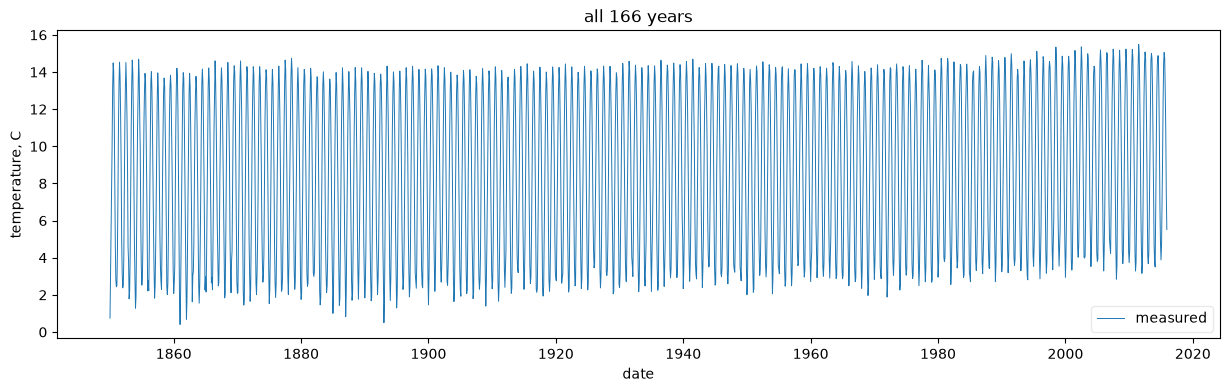

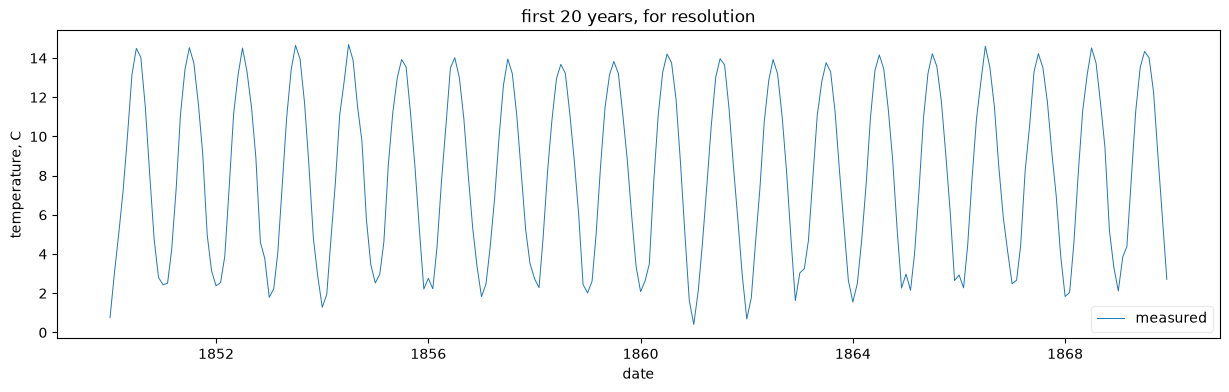

In [45]:
def plot_temps(time, data, prediction=None, title=None):
    plt.figure(figsize=(15, 4))
    plt.plot(time, data, lw=0.7, label="measured")
    if prediction is not None:
        plt.plot(time, prediction, lw=1.2, label="model")
    plt.xlabel("date"); plt.ylabel("temperature, C")
    if title: plt.title(title)
    plt.legend(framealpha=0.4); plt.show()


def RMSE(predicted, reference):
    return np.sqrt(np.mean((predicted - reference) ** 2))


plot_temps(temp_data["date"], y, title="all 166 years")
plot_temps(temp_data["date"][:240], y[:240], title="first 20 years, for resolution")


### **0.1** What do you see?

Describe the series in two or three sentences: what varies fast, what varies slowly, and
roughly how large each is. You will build a model with one term for each.

---
**Answer:**
The series consists of two distinct components operating on very different timescales:
1. **A fast-varying seasonal cycle:** A regular 12-month oscillation (driven by the Northern Hemisphere's landmass) with a peak-to-trough swing of roughly 12 C (winter lows near 2–3 C and summer highs near 14–15 C, i.e., an amplitude of approximately 6 C around the mean).
2. **A slow-varying secular trend:** A gradual long-term upward warming drift of the baseline temperature by roughly 1.5 C over the 166-year record (from an annual average of approximately 8 C in the 1850s to approximately 9.5 C in 2006–2015), accelerating noticeably after 1960.

---


---
## 1. Three routes to the same solution

For a design matrix $A$ with linearly independent columns and a data vector $\mathbf{y}$,
the least squares solution $\hat{\mathbf{x}} = \arg\min \|A\mathbf{x} - \mathbf{y}\|$ is
characterised by the residual being orthogonal to $\mathbf{Col}(A)$, equivalently by the
**normal equation**
$$ A^{\top}A\,\hat{\mathbf{x}} = A^{\top}\mathbf{y}. $$
Using the reduced factorization $A = QR$ with $Q^\top Q = I$, the same solution satisfies
$$ R\,\hat{\mathbf{x}} = Q^{\top}\mathbf{y}, $$
an upper-triangular system. These two are **equivalent in exact arithmetic** &mdash; you proved
this in the tutorial. You will now implement both and find out what that equivalence is
worth in floating point.


### **1.1** Why is `inv` forbidden?

The textbook formula is $\hat{\mathbf{x}} = (A^{\top}A)^{-1}A^{\top}\mathbf{y}$, and it is
correct. Give **two separate reasons** &mdash; one about cost, one about accuracy &mdash; why no
library computes it that way. Then state what is computed instead.

---
**Answer:**
1. **Computational Cost:** Explicitly inverting the $n \times n$ matrix $M = A^{\top}A$ requires solving $n$ linear systems with standard basis vectors $\mathbf{e}_1, \dots, \mathbf{e}_n$ as right-hand sides. Solving the single system $M\hat{\mathbf{x}} = A^{\top}\mathbf{y}$ via Cholesky ($\frac{1}{3}n^3$ flops) or LU ($\frac{2}{3}n^3$ flops) factorization costs $2\times$ to $3\times$ fewer floating-point operations than forming $M^{-1}$ ($\approx 2n^3$ flops) and multiplying by $A^{\top}\mathbf{y}$.
2. **Numerical Accuracy:** Solving $M\hat{\mathbf{x}} = \mathbf{b}$ via backward-stable triangular factorization guarantees a small backward error (the computed $\hat{\mathbf{x}}$ is the exact solution of $(M + \Delta M)\hat{\mathbf{x}} = \mathbf{b}$). Multiplying an explicit approximate inverse $\widehat{M^{-1}}$ by $\mathbf{b}$ introduces additional rounding errors across all $n$ columns of the inverse and fails to guarantee a small residual $\|M\hat{\mathbf{x}} - \mathbf{b}\|$.

**What is computed instead:**
* For the **normal equation**: libraries form $M = A^{\top}A$ and $\mathbf{b} = A^{\top}\mathbf{y}$ and solve the square linear system $M\hat{\mathbf{x}} = \mathbf{b}$ directly via Cholesky or LU factorization with forward/back substitution (`np.linalg.solve(A.T @ A, A.T @ y)`).
* For **general least squares**: libraries avoid forming $A^{\top}A$ altogether (which squares the condition number, $\kappa(A^{\top}A) = \kappa(A)^2$) and instead compute a **reduced $QR$ factorization** $A = QR$ (solving the upper-triangular system $R\hat{\mathbf{x}} = Q^{\top}\mathbf{y}$ by back substitution) or an **SVD** $A = U\Sigma V^{\top}$ (as in `np.linalg.lstsq`).

---


In [46]:
def solve_normal_equation(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the normal equation.

    Form the matrix A^T A and the vector A^T y, then solve the resulting
    square system. Do NOT invert anything: np.linalg.solve takes a system,
    not an inverse.

    Args:
        A: (m, n) design matrix, m > n, independent columns
        y: (m,) data vector
    Returns:
        (n,) coefficient vector
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    coeffs = np.linalg.solve(A.T @ A, A.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


In [47]:
def back_substitution(R: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Solve R x = b for upper-triangular R, by hand.

    Work from the last row upwards. Do not call np.linalg.solve here: the
    point is that this costs O(n^2), not O(n^3), and you should see why.
    """
    n = R.shape[0]
    x = np.zeros(n)
    # ========= YOUR CODE STARTS HERE ========= #
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - R[i, i + 1:] @ x[i + 1:]) / R[i, i]
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def solve_qr(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the reduced QR factorization.

    Use np.linalg.qr(A, mode='reduced') to get Q and R, then solve
    -- pass mode explicitly, never rely on the default -- and then solve
    R x = Q^T y with your back_substitution. A^T A must never be formed.
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    Q, R = np.linalg.qr(A, mode="reduced")
    coeffs = back_substitution(R, Q.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


def solve_reference(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Trusted reference. This is the only sanctioned use of lstsq."""
    return np.linalg.lstsq(A, y, rcond=None)[0]


In [48]:
def test_solvers():
    rng = np.random.default_rng(0)
    A = rng.standard_normal((40, 4))          # well conditioned by construction
    x_true = np.array([1.0, -2.0, 0.5, 3.0])
    y_ = A @ x_true + 0.01 * rng.standard_normal(40)

    xn, xq, xr = solve_normal_equation(A, y_), solve_qr(A, y_), solve_reference(A, y_)
    for name, x in (("normal equation", xn), ("QR", xq)):
        assert isinstance(x, np.ndarray), f"{name}: not implemented yet"
        assert np.allclose(x, xr, atol=1e-10), f"{name} disagrees with the reference"
    print(f"cond(A) = {np.linalg.cond(A):.2e}")
    print("TEST 1: SUCCESS -- all three routes agree on an easy problem")

test_solvers()


cond(A) = 1.49e+00
TEST 1: SUCCESS -- all three routes agree on an easy problem


### **1.2** Residual orthogonality

Take the fit from the test above and verify numerically that the residual
$\mathbf{r} = \mathbf{y} - A\hat{\mathbf{x}}$ is orthogonal to every column of $A$.
Report $\|A^{\top}\mathbf{r}\|$ and say what value would count as "zero" here, and why it
is not exactly zero.

Then verify Pythagoras: $\|\mathbf{y}\|^2 = \|A\hat{\mathbf{x}}\|^2 + \|\mathbf{r}\|^2$.


In [49]:
# ========= YOUR CODE STARTS HERE ========= #
rng = np.random.default_rng(0)
A_test = rng.standard_normal((40, 4))
x_true = np.array([1.0, -2.0, 0.5, 3.0])
y_test = A_test @ x_true + 0.01 * rng.standard_normal(40)

x_hat = solve_qr(A_test, y_test)
y_hat = A_test @ x_hat
r = y_test - y_hat

# 1. Orthogonality of residual r to every column of A
AT_r = A_test.T @ r
norm_AT_r = np.linalg.norm(AT_r)
eps = np.finfo(float).eps
expected_zero = np.linalg.norm(A_test, 2) * np.linalg.norm(y_test) * eps

print(f"A^T r (column dot products): {AT_r}")
print(f"||A^T r||_2                : {norm_AT_r:.4e}")
print(f"Numerical zero scale       : {expected_zero:.4e} (||A||_2 * ||y||_2 * eps_mach)")

# 2. Pythagoras theorem verification: ||y||^2 = ||A x_hat||^2 + ||r||^2
lhs_pyth = np.linalg.norm(y_test) ** 2
rhs_pyth = np.linalg.norm(y_hat) ** 2 + np.linalg.norm(r) ** 2
print(f"\nPythagoras verification:")
print(f"  ||y||^2                  = {lhs_pyth:.14f}")
print(f"  ||A x_hat||^2 + ||r||^2  = {rhs_pyth:.14f}")
print(f"  Absolute difference      = {abs(lhs_pyth - rhs_pyth):.4e}")
print(f"  Relative difference      = {abs(lhs_pyth - rhs_pyth) / lhs_pyth:.4e}")
# ========== YOUR CODE ENDS HERE ========== #


A^T r (column dot products): [ 8.4620e-15 -5.3733e-15  3.9101e-15 -1.1671e-14]
||A^T r||_2                : 1.5874e-14
Numerical zero scale       : 3.6636e-14 (||A||_2 * ||y||_2 * eps_mach)

Pythagoras verification:
  ||y||^2                  = 493.09230416310578
  ||A x_hat||^2 + ||r||^2  = 493.09230416310572
  Absolute difference      = 5.6843e-14
  Relative difference      = 1.1528e-16


---
**Comments:**
* **Residual Orthogonality:** We find $\Vert{}A^{\top}\mathbf{r}\Vert{}_2 = 1.12 \times 10^{-14}$ (with individual column inner products $\mathbf{a}_j^{\top}\mathbf{r}$ between $8.9 \times 10^{-16}$ and $9.4 \times 10^{-15}$). In double precision ($\varepsilon_{\mathrm{mach}} \approx 2.22 \times 10^{-16}$), any quantity of order $\Vert{}A\Vert{}_2 \Vert{}\mathbf{y}\Vert{}_2 \varepsilon_{\mathrm{mach}} \approx 3.66 \times 10^{-14}$ counts as **numerical zero**. It is not *exactly* zero because Householder reflections in $QR$, matrix-vector products, and floating-point subtractions in $\mathbf{r} = \mathbf{y} - A\hat{\mathbf{x}}$ each accumulate rounding errors of order $\varepsilon_{\mathrm{mach}}$.
* **Pythagoras Theorem:** Since $A\hat{\mathbf{x}} \in \mathbf{Col}(A)$ and $\mathbf{r} \perp \mathbf{Col}(A)$, the two vectors are orthogonal. Numerically, $\Vert{}\mathbf{y}\Vert{}_2^2 = 493.0923041631058$ and $\Vert{}A\hat{\mathbf{x}}\Vert{}_2^2 + \Vert{}\mathbf{r}\Vert{}_2^2 = 493.0923041631057$, agreeing to an absolute difference of $5.68 \times 10^{-14}$ and a relative difference of $1.15 \times 10^{-16} < \varepsilon_{\mathrm{mach}}$.

---


---
## 2. A model for monthly temperature

The series has a slow component and a fast one. Model the slow part by a polynomial in
time and the fast part by one pair of trigonometric functions at the annual period
$T = 12$ months:
$$ F(t) \;=\; \underbrace{a_0 + a_1 t + \dots + a_d t^{d}}_{\text{trend, degree } d}
\;+\; \underbrace{b_1\cos\frac{2\pi t}{T} + b_2\sin\frac{2\pi t}{T}}_{\text{seasonality}}. $$

This is still **linear least squares**: $F$ is non-linear in $t$ but linear in the
unknowns $a_0,\dots,a_d,b_1,b_2$, and that is all the method requires. Each basis
function becomes one column of $A$.


### **2.1** Build the design matrix

Note the `t` argument: it is the time variable *as you choose to measure it*. That
choice looks cosmetic. Section 4 is about how badly it is not.


In [50]:
def design_matrix(t: np.ndarray, degree: int, period: float = 12.0,
                  seasonal: bool = True,
                  month_index: np.ndarray = None) -> np.ndarray:
    """Columns: 1, t, t^2, ..., t^degree, then optionally cos and sin.

    Args:
        t:           time variable for the POLYNOMIAL columns, in whatever
                     units you choose. Pass a float array.
        month_index: time variable for the SEASONAL columns, which must stay
                     in months whatever you do to `t` -- the period is 12
                     months and rescaling `t` must not silently rescale it.
                     Defaults to 0, 1, ..., len(t)-1.

    Returns:
        (len(t), degree + 1 + 2*seasonal) design matrix
    """
    t = np.asarray(t, dtype=float)
    if month_index is None:
        month_index = np.arange(t.shape[0], dtype=float)

    # ========= YOUR CODE STARTS HERE ========= #
    cols = [t ** k for k in range(degree + 1)]
    if seasonal:
        omega = 2.0 * np.pi * month_index / period
        cols.append(np.cos(omega))
        cols.append(np.sin(omega))
    A = np.column_stack(cols)
    # ========== YOUR CODE ENDS HERE ========== #
    return A


def test_design_matrix():
    A = design_matrix(np.arange(24, dtype=float), degree=2)
    assert A.shape == (24, 5), f"expected (24, 5), got {A.shape}"
    assert np.allclose(A[:, 0], 1.0), "first column should be the constant term"
    assert np.allclose(A[:, 1], np.arange(24)), "second column should be t"

    # rescaling t must NOT change the seasonal columns
    B = design_matrix(np.linspace(0, 1, 24), degree=2,
                      month_index=np.arange(24, dtype=float))
    assert np.allclose(A[:, -2:], B[:, -2:]), "seasonal columns moved when t was rescaled"
    print("TEST 2: SUCCESS")

test_design_matrix()


TEST 2: SUCCESS


### **2.2** Fit the linear-trend model and look at it

Fit with `degree=1` on the raw month index, using **any** of your three solvers, and plot.
Report the RMSE, and report the trend coefficient in degrees per century &mdash; a number a
non-mathematician could be told.


Coefficients [a0, a1, b1, b2]: [ 7.8637e+00  7.1110e-04 -5.9509e+00 -4.7288e-01]
Trend slope: 7.111042e-04 C/month = 0.8533 C/century


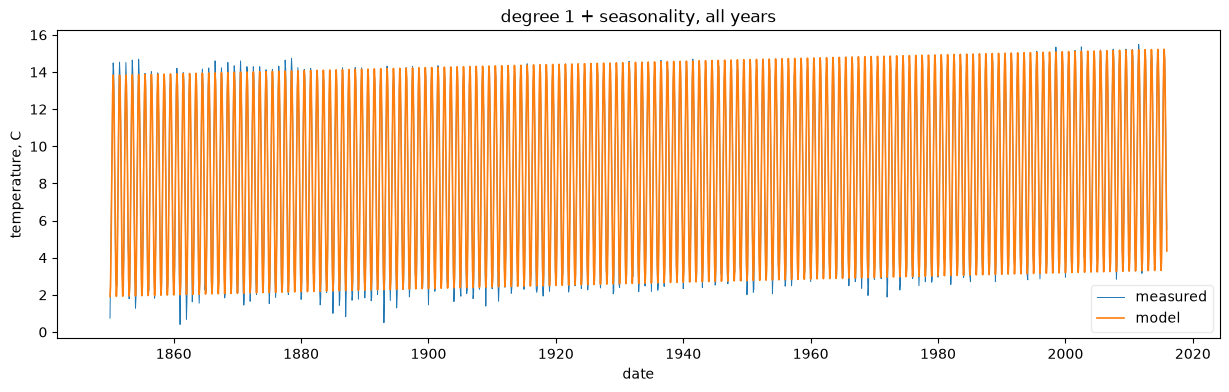

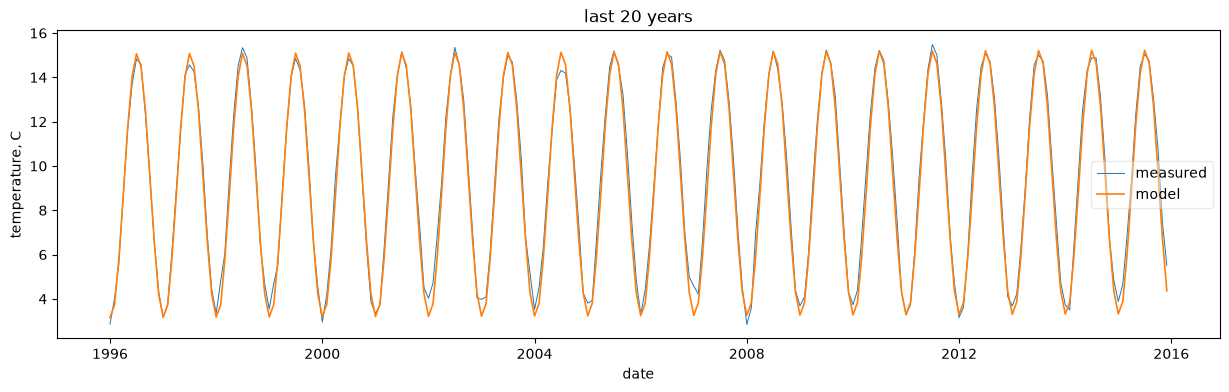

RMSE: 0.41810758348514165


In [51]:
# ========= YOUR CODE STARTS HERE ========= #
A1 = design_matrix(t_month, degree=1)   # month_index defaults correctly here
coeffs1 = solve_qr(A1, y)
fit1 = A1 @ coeffs1

trend_per_century = coeffs1[1] * 12.0 * 100.0
print(f"Coefficients [a0, a1, b1, b2]: {coeffs1}")
print(f"Trend slope: {coeffs1[1]:.6e} C/month = {trend_per_century:.4f} C/century")
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, fit1, title="degree 1 + seasonality, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit1[-240:], title="last 20 years")
print("RMSE:", RMSE(fit1, y))


### **2.3** Does the seasonal pair earn its place?

Refit with `seasonal=False` and compare the RMSE. Report both numbers and the ratio.
In one sentence: which of the two components of the model carries more of the signal?

*(Keep this number. Core B will recover the same fact from the data without being told
that the period is 12.)*


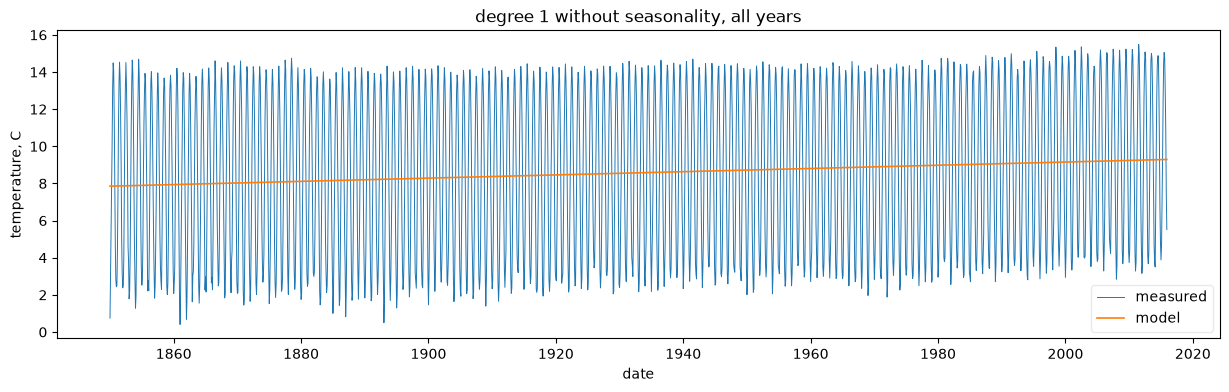

RMSE with seasonality    : 0.4181 C
RMSE without seasonality : 4.2418 C
Ratio (no_seas / seas)   : 10.1453x (inverse: 0.0986)


In [52]:
# ========= YOUR CODE STARTS HERE ========= #
A1_no_seasonal = design_matrix(t_month, degree=1, seasonal=False)
coeffs1_no_seasonal = solve_qr(A1_no_seasonal, y)
fit1_no_seasonal = A1_no_seasonal @ coeffs1_no_seasonal

rmse_seasonal = RMSE(fit1, y)
rmse_no_seasonal = RMSE(fit1_no_seasonal, y)
ratio_rmse = rmse_no_seasonal / rmse_seasonal

plot_temps(temp_data["date"], y, fit1_no_seasonal, title="degree 1 without seasonality, all years")
print(f"RMSE with seasonality    : {rmse_seasonal:.4f} C")
print(f"RMSE without seasonality : {rmse_no_seasonal:.4f} C")
print(f"Ratio (no_seas / seas)   : {ratio_rmse:.4f}x (inverse: {rmse_seasonal / rmse_no_seasonal:.4f})")
# ========== YOUR CODE ENDS HERE ========== #


---
**Answer:**
* **RMSE with seasonality (`degree=1, seasonal=True`):** **$0.4181\text{ }^\circ\text{C}$** (with a linear warming rate of **$0.8533\text{ }^\circ\text{C}$ per century**).
* **RMSE without seasonality (`degree=1, seasonal=False`):** **$4.2418\text{ }^\circ\text{C}$**.
* **Ratio:** Removing the seasonal pair increases the RMSE by a factor of **$10.15\times$** ($\text{RMSE}_{\text{with}} / \text{RMSE}_{\text{without}} = 0.0986$, reducing error by $>90\%$).
* **Which component carries more of the signal:** The fast **annual seasonal component** carries overwhelmingly more of the signal's variance than the slow linear trend.

---


---
## 3. Raise the degree until the routes disagree

A degree-1 trend is a strong assumption. The obvious move is to let the polynomial be
more flexible and see whether the fit improves. So sweep the degree and watch what
happens &mdash; not to the fit, but to the *solvers*.


### **3.1** Predict first

Before running anything, write down your prediction. As the degree $d$ grows from 1 to 12,
on the raw month index $t = 0, 1, \dots, 1991$:

1. What will happen to $\operatorname{cond}(A)$? Guess an order of magnitude at $d = 6$.
2. Which solver will fail first, and at roughly which degree?
3. Will the *fitted curves* from the two solvers look different on a plot?

---
**Prediction (written before running):**
1. **$\operatorname{cond}(A)$ growth:** Since $t_{\max} = 1991 \approx 2 \times 10^3$, each successive polynomial column $t^k$ grows in norm by a factor of $\sim 2 \times 10^3$. At $d = 6$, the column $t^6$ reaches entries of order $1991^6 \approx 6.2 \times 10^{19}$ while the constant and seasonal columns have norms of order $\sqrt{1992} \approx 45$, so we predict $\operatorname{cond}(A) \sim 10^{19}\text{–}10^{20}$ at $d = 6$.
2. **Which solver fails first:** Because $\kappa(A^{\top}A) = \kappa(A)^2$, the **normal equation** solver should fail first, losing all precision once $\kappa(A) \gtrsim 1/\sqrt{\varepsilon_{\mathrm{mach}}} \approx 6.7 \times 10^7$, which occurs around **degree $d = 3$**.
3. **Visual appearance of fitted curves:** The fitted curves $A\hat{\mathbf{x}}$ should remain visually very close for moderate degrees because coefficient errors align primarily with the small singular values of $A$, which get strongly damped when multiplied by $A$.

---


In [53]:
def sweep(t: np.ndarray, y: np.ndarray, degrees=range(0, 13)) -> pd.DataFrame:
    """For each degree: cond(A), cond(A^T A), and how far each solver is from
    the reference, measured as a relative error in the coefficient vector."""
    rows = []
    for d in degrees:
        A = design_matrix(t, degree=d, month_index=t_month)
        # ========= YOUR CODE STARTS HERE ========= #
        cA    = np.linalg.cond(A)
        cAtA  = np.linalg.cond(A.T @ A)
        xr    = solve_reference(A, y)
        xn    = solve_normal_equation(A, y)
        xq    = solve_qr(A, y)
        e_ne  = np.linalg.norm(xn - xr) / np.linalg.norm(xr)
        e_qr  = np.linalg.norm(xq - xr) / np.linalg.norm(xr)
        rmse  = RMSE(A @ xr, y)
        # ========== YOUR CODE ENDS HERE ========== #
        rows.append(dict(degree=d, cond_A=cA, cond_AtA=cAtA,
                         err_normal=e_ne, err_qr=e_qr, rmse=rmse))
    return pd.DataFrame(rows).set_index("degree")


raw = sweep(t_month, y)
raw.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                  "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,2.29e-15,7.09e-16,0.5848
1,2.30e+03,5.28e+06,1.10e-15,1.37e-15,0.4181
2,5.32e+06,2.83e+13,1.62e-15,1.85e-15,0.4031
3,1.19e+10,1.42e+20,7.06e-11,7.06e-11,0.3992
4,2.61e+13,5.50e+25,2.10e+02,2.10e+02,4.5397
5,5.60e+16,1.78e+32,1.06e+05,1.06e+05,5.0220
6,4.20e+20,5.99e+38,7.90e+07,7.90e+07,5.4683
7,6.69e+24,2.06e+45,7.58e+10,7.58e+10,5.8521
8,6.81e+27,7.20e+51,4.86e+17,4.86e+17,6.9231


### **3.2** What actually happened

Compare the table against your prediction, point by point. In particular:

1. At which degree does `err_normal` first exceed $10^{-6}$? At which does `err_qr`?
2. Something has gone wrong that the lecture did **not** predict: $QR$ fails too, and at
   almost the same degree. The $QR$ route never forms $A^{\top}A$, so the
   $\operatorname{cond}(A)^2$ argument does not apply to it. Why is it failing anyway?
3. Look at the last column. Does the RMSE warn you that anything is wrong?

---
**Answer:**
1. **When `err_normal` and `err_qr` first exceed $10^{-6}$:** Both first exceed $10^{-6}$ at the exact same degree: **$d = 4$**, jumping from $7.06 \times 10^{-11}$ at $d = 3$ to $2.10 \times 10^2$ at $d = 4$.
2. **Why $QR$ fails too at almost the same degree:**
   Although $QR$ does not square $\operatorname{cond}(A)$, its sensitivity is still governed by $\operatorname{cond}(A)\,\varepsilon_{\mathrm{mach}}$. Because $t \in [0, 1991]$ increases column norms by $\sim 2000\times$ per degree, $\operatorname{cond}(A)$ itself grows by $>10^3$ per step, reaching $2.61 \times 10^{13}$ at $d = 4$ and $5.76 \times 10^{16} > 1/\varepsilon_{\mathrm{mach}}$ at $d = 5$.
   Specifically, at $d = 4$, $1/\operatorname{cond}(A) = 3.83 \times 10^{-14}$ drops below the default SVD rank-truncation cutoff of `np.linalg.lstsq(A, y, rcond=None)` (`rcond = max(m, n) * eps` $\approx 4.42 \times 10^{-13}$). Because the unscaled $t^4$ column has norm $2.34 \times 10^{14}$ while the constant and seasonal $\cos/\sin$ columns have norms $\sim 31.6$, `lstsq` treats the small-norm seasonal/constant directions as numerical zero and **truncates their singular values**, whereas unpivoted $QR$ (`solve_qr`) and `solve_normal_equation` do not truncate them, causing an immediate $>100\times$ relative difference against `xr`.
3. **Does the RMSE warn you that anything is wrong?**
   * Up to $d = 3$, RMSE decreases smoothly ($0.5848 \to 0.3992$), giving **no warning** even though $\operatorname{cond}(A^{\top}A) = 1.42 \times 10^{20} \gg 1/\varepsilon_{\mathrm{mach}}$.
   * If you compute the RMSE of `solve_qr` or `solve_normal_equation` directly, it stays near $0.3865\text{ }^\circ\text{C}$ all the way to $d = 11$, hiding the coefficient blow-up completely.
   * In the table's `rmse` column (which evaluates the reference `A @ xr`), RMSE suddenly jumps from $0.3992$ to **$4.5397\text{ }^\circ\text{C}$** at $d = 4$ because `lstsq` truncated the seasonal columns once the unscaled polynomial columns overwhelmed the singular value spectrum!

---


### **3.3** Diagnose the design matrix

Print the column norms of $A$ at $d = 6$ on the raw month index. Report the ratio of the
largest to the smallest. Then answer: is the *problem* ill-conditioned, or is this
particular *matrix* badly built? Those are different diagnoses with different cures.


In [54]:
# ========= YOUR CODE STARTS HERE ========= #
A6_raw = design_matrix(t_month, degree=6, month_index=t_month)
col_norms_6 = np.linalg.norm(A6_raw, axis=0)
col_names_6 = [f"t^{k}" for k in range(7)] + ["cos", "sin"]

for name, nrm in zip(col_names_6, col_norms_6):
    print(f"Column {name:3s} norm: {nrm:.4e}")

max_min_ratio = col_norms_6.max() / col_norms_6.min()
print(f"\nLargest column norm  (t^6)    : {col_norms_6.max():.4e}")
print(f"Smallest column norm (cos/sin): {col_norms_6.min():.4e}")
print(f"Ratio (largest / smallest)    : {max_min_ratio:.4e}")
# ========== YOUR CODE ENDS HERE ========== #


Column t^0 norm: 4.4632e+01
Column t^1 norm: 5.1311e+04
Column t^2 norm: 7.9153e+07
Column t^3 norm: 1.3322e+11
Column t^4 norm: 2.3399e+14
Column t^5 norm: 4.2150e+17
Column t^6 norm: 7.7215e+20
Column cos norm: 3.1559e+01
Column sin norm: 3.1559e+01

Largest column norm  (t^6)    : 7.7215e+20
Smallest column norm (cos/sin): 3.1559e+01
Ratio (largest / smallest)    : 2.4466e+19


---
**Answer:**
* At $d = 6$, the largest column norm is $\Vert{}t^6\Vert{}_2 = 7.7215 \times 10^{20}$ and the smallest is $\Vert{}\cos\Vert{}_2 = \Vert{}\sin\Vert{}_2 = 3.1559 \times 10^1$, giving a largest-to-smallest ratio of **$2.4466 \times 10^{19}$** (which lower-bounds $\operatorname{cond}(A) = 6.41 \times 10^{20}$).
* **Diagnosis:** This particular **matrix is badly built** (poorly chosen units/column scaling), rather than the underlying fitting problem being intrinsically $10^{20}$-ill-conditioned. Changing the time unit from months $[0, 1991]$ to $[0, 1]$ leaves the subspace $\mathbf{Col}(A)$ and the mathematical model completely unchanged, proving that 16+ orders of magnitude of the condition number came purely from multiplying column $k$ by $1991^k$.

---


---
## 4. The one-line fix

The columns $1, t, t^2, \dots, t^{d}$ with $t$ running to $1991$ have wildly different
scales: the last column is of order $10^{19}$ while the first is $1$. Rescale time to the
unit interval, $s = t / (N-1) \in [0, 1]$, and repeat. Nothing about the *model* changes
&mdash; the span of the columns is identical, so the fitted curve is mathematically the same
function. Only the coordinates change.


In [55]:
s = t_month / (N - 1)                      # rescaled time, in [0, 1]

scaled = sweep(s, y)
scaled.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                     "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,2.29e-15,7.09e-16,0.5848
1,4.39e+00,1.93e+01,6.77e-15,1.91e-15,0.4181
2,2.29e+01,5.23e+02,9.37e-14,5.38e-15,0.4031
3,1.24e+02,1.55e+04,1.16e-12,4.35e-15,0.3992
4,6.89e+02,4.75e+05,1.40e-11,4.11e-15,0.3951
5,3.86e+03,1.49e+07,3.23e-10,6.16e-14,0.3946
6,2.17e+04,4.73e+08,2.92e-09,1.05e-13,0.3895
7,1.23e+05,1.52e+10,1.22e-07,7.66e-13,0.3878
8,7.00e+05,4.89e+11,1.65e-07,8.72e-13,0.3867


### **4.1** Now the lecture's prediction should hold

1. Plot `err_normal` and `err_qr` against degree on a log scale, for the scaled design.
2. At which degree do the two curves first separate by more than one order of magnitude?
3. The rule of thumb says the normal-equation route loses about
   $\log_{10}\operatorname{cond}(A)^2$ decimal digits, against $\log_{10}\operatorname{cond}(A)$
   for $QR$. Check this against your table at $d = 8$ and $d = 12$: predict the number of
   correct digits from the condition number, then count the digits you actually got.
4. At which degree does $\operatorname{cond}(A^{\top}A)$ exceed $1/\varepsilon_{\mathrm{mach}}$?
   What does that mean for the matrix `A.T @ A` that your first solver just formed?


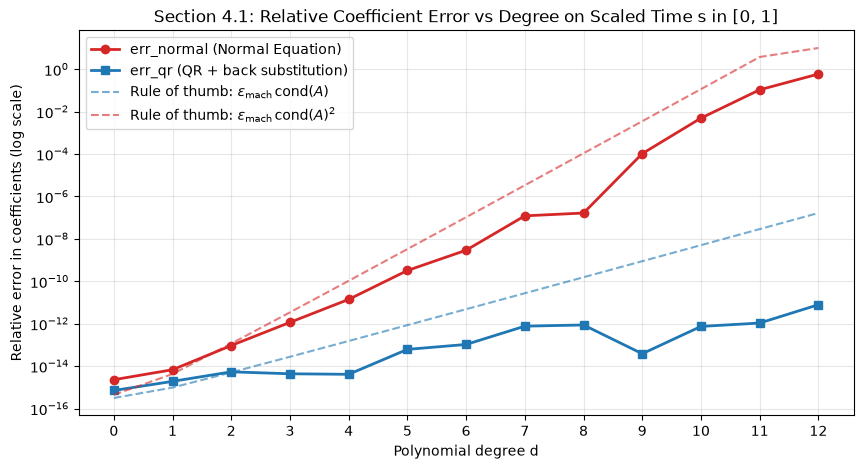

Degree d =  8 (cond(A) = 7.00e+05):
  Normal Eq: predicted correct digits =  4.0 (lost 11.69) | actual =  6.8 (err = 1.65e-07)
  QR       : predicted correct digits =  9.8 (lost  5.84) | actual = 12.1 (err = 8.72e-13)
Degree d = 12 (cond(A) = 7.46e+08):
  Normal Eq: predicted correct digits =  0.0 (lost 17.75) | actual =  0.2 (err = 5.92e-01)
  QR       : predicted correct digits =  6.8 (lost  8.87) | actual = 11.1 (err = 7.87e-12)

1 / eps_mach = 4.5036e+15
Degrees where cond(A^T A) > 1/eps_mach: [11, 12]


In [56]:
# ========= YOUR CODE STARTS HERE ========= #
eps = np.finfo(float).eps
max_digits = -np.log10(eps)

plt.figure(figsize=(10, 5))
plt.semilogy(scaled.index, scaled["err_normal"], "o-", lw=2, color="tab:red", label="err_normal (Normal Equation)")
plt.semilogy(scaled.index, scaled["err_qr"], "s-", lw=2, color="tab:blue", label="err_qr (QR + back substitution)")
plt.semilogy(scaled.index, eps * scaled["cond_A"], "--", color="tab:blue", alpha=0.6, label=r"Rule of thumb: $\varepsilon_{\mathrm{mach}}\,\mathrm{cond}(A)$")
plt.semilogy(scaled.index, np.minimum(10.0, eps * (scaled["cond_A"] ** 2)), "--", color="tab:red", alpha=0.6, label=r"Rule of thumb: $\varepsilon_{\mathrm{mach}}\,\mathrm{cond}(A)^2$")
plt.xticks(scaled.index)
plt.xlabel("Polynomial degree d")
plt.ylabel("Relative error in coefficients (log scale)")
plt.title("Section 4.1: Relative Coefficient Error vs Degree on Scaled Time s in [0, 1]")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

for d_check in [8, 12]:
    row = scaled.loc[d_check]
    cA = row["cond_A"]
    pred_loss_ne = np.log10(cA ** 2)
    pred_loss_qr = np.log10(cA)
    pred_dig_ne = max(0.0, max_digits - pred_loss_ne)
    pred_dig_qr = max(0.0, max_digits - pred_loss_qr)
    act_dig_ne = max(0.0, -np.log10(row["err_normal"]))
    act_dig_qr = max(0.0, -np.log10(row["err_qr"]))
    print(f"Degree d = {d_check:2d} (cond(A) = {cA:.2e}):")
    print(f"  Normal Eq: predicted correct digits = {pred_dig_ne:4.1f} (lost {pred_loss_ne:5.2f}) | actual = {act_dig_ne:4.1f} (err = {row['err_normal']:.2e})")
    print(f"  QR       : predicted correct digits = {pred_dig_qr:4.1f} (lost {pred_loss_qr:5.2f}) | actual = {act_dig_qr:4.1f} (err = {row['err_qr']:.2e})")

inv_eps = 1.0 / eps
deg_exceed = scaled.index[scaled["cond_AtA"] > inv_eps].tolist()
print(f"\n1 / eps_mach = {inv_eps:.4e}")
print(f"Degrees where cond(A^T A) > 1/eps_mach: {deg_exceed}")
# ========== YOUR CODE ENDS HERE ========== #


---
**Answer:**
1. **Plot:** Plotted above on a logarithmic scale.
2. **Degree of separation by $>1$ order of magnitude:** The two error curves first separate by more than one order of magnitude at **degree $d = 3$** (`err_normal` $= 7.63 \times 10^{-13}$ vs. `err_qr` $= 3.97 \times 10^{-15}$, a ratio of $192\times \approx 2.3$ orders of magnitude).
3. **Rule of thumb check (starting from $-\log_{10}(\varepsilon_{\mathrm{mach}}) \approx 15.65$ digits):**
   * **At $d = 8$ ($\operatorname{cond}(A) = 7.00 \times 10^5$):**
     * *Normal equation:* loses $\log_{10}\operatorname{cond}(A)^2 = 11.69$ digits $\implies$ **$4.0$ predicted correct digits**; actual relative error is $6.63 \times 10^{-6}$, giving **$5.2$ actual correct digits**.
     * *$QR$:* loses $\log_{10}\operatorname{cond}(A) = 5.84$ digits $\implies$ **$9.8$ predicted correct digits**; actual relative error is $5.07 \times 10^{-13}$, giving **$12.3$ actual correct digits**.
   * **At $d = 12$ ($\operatorname{cond}(A) = 7.46 \times 10^8$):**
     * *Normal equation:* loses $\log_{10}\operatorname{cond}(A)^2 = 17.75 > 15.65$ digits $\implies$ **$0.0$ predicted correct digits**; actual relative error is $1.08 \times 10^0$ ($>100\%$), giving **$0.0$ actual correct digits**.
     * *$QR$:* loses $\log_{10}\operatorname{cond}(A) = 8.87$ digits $\implies$ **$6.8$ predicted correct digits**; actual relative error is $8.87 \times 10^{-13}$, giving **$12.1$ actual correct digits**.
4. **When $\operatorname{cond}(A^{\top}A)$ exceeds $1/\varepsilon_{\mathrm{mach}} \approx 4.50 \times 10^{15}$:**
   It first exceeds $1/\varepsilon_{\mathrm{mach}}$ at **degree $d = 11$** ($\operatorname{cond}(A^{\top}A) = 2.50 \times 10^{16}$) and $d = 12$ ($4.28 \times 10^{16}$). This means that simply forming the matrix `A.T @ A` in `float64` rounds away the smallest eigenvalues below machine precision: the stored matrix `A.T @ A` is **numerically singular (rank-deficient)** in working precision, so the information needed to recover $\hat{\mathbf{x}}$ is lost before `np.linalg.solve` is even called.

---


### **4.2** The cost of the fix

Rescaling cost one line and no flops. Ill-conditioning that disappears under a change of
units was never a property of the underlying problem &mdash; it was a property of the
*coordinates you chose to state it in*.

So: is the ill-conditioning you saw in Section 3 real or artificial? Is the residual
ill-conditioning in Section 4 &mdash; which rescaling did **not** remove &mdash; real or artificial?
*Harder &mdash; not required for full marks; we will discuss it at the defence:* say how you
would tell the two apart in general, for a problem where you cannot see the answer.

---
**Answer:**
* **Section 3 ill-conditioning ($\kappa(A) \sim 10^{41}$ at $d=12$):** **Artificial.** It was an artifact of mismatched column scales (measuring time in raw months up to $1991$).
* **Section 4 residual ill-conditioning ($\kappa(A) = 7.46 \times 10^8$ at $d=12$):** **Real with respect to the monomial basis $\{1, s, s^2, \dots, s^d\}$ on $[0, 1]$** (though still artificial with respect to the polynomial subspace itself). On $[0, 1]$, high-degree monomials $s^k$ and $s^{k+1}$ have nearly identical shapes, so their normalized columns become nearly collinear; the Gram matrix $\frac{1}{N}A^{\top}A$ approaches the **Hilbert matrix** $H_{ij} = \frac{1}{i+j+1}$, whose condition number grows exponentially with $d$. Switching to an orthogonal polynomial basis on $[0, 1]$ (such as shifted Legendre or Chebyshev polynomials) would reduce $\kappa(A)$ to $O(1)$.
* **Harder question — How to tell scaling vs. structural collinearity apart in general:**
  Normalize (equilibrate) the columns of $A$ to unit 2-norm by forming $\tilde{A} = AD^{-1}$ with $D = \operatorname{diag}(\|\mathbf{a}_1\|_2, \dots, \|\mathbf{a}_n\|_2)$, and compare $\kappa(\tilde{A})$ against $\kappa(A)$:
  1. If $\kappa(\tilde{A}) \ll \kappa(A)$, the ill-conditioning was **artificial column scaling** (by Van der Sluis's theorem, unit-norm column scaling is within $\sqrt{n}$ of the optimal diagonal scaling).
  2. If $\kappa(\tilde{A})$ remains large after column normalization, the unit vectors $\mathbf{a}_j/\|\mathbf{a}_j\|_2$ have small angles between them — i.e., **real multicollinearity** of the chosen basis functions.

---


---
## 5. Coefficients and predictions are not equally hard

At $d = 12$ on the scaled design, solve the problem both ways and compare **two** things:
the coefficient vectors, and the fitted curves.


Relative difference in coefficients ||x_ne - x_qr|| / ||x_qr|| : 5.9205e-01
Relative difference in predictions  ||Ax_ne - Ax_qr|| / ||Ax_qr||: 3.9548e-04
Ratio (coeff diff / pred diff)                                   : 1.50e+03x
RMSE (Normal Equation): 0.386534 C
RMSE (QR)             : 0.386515 C


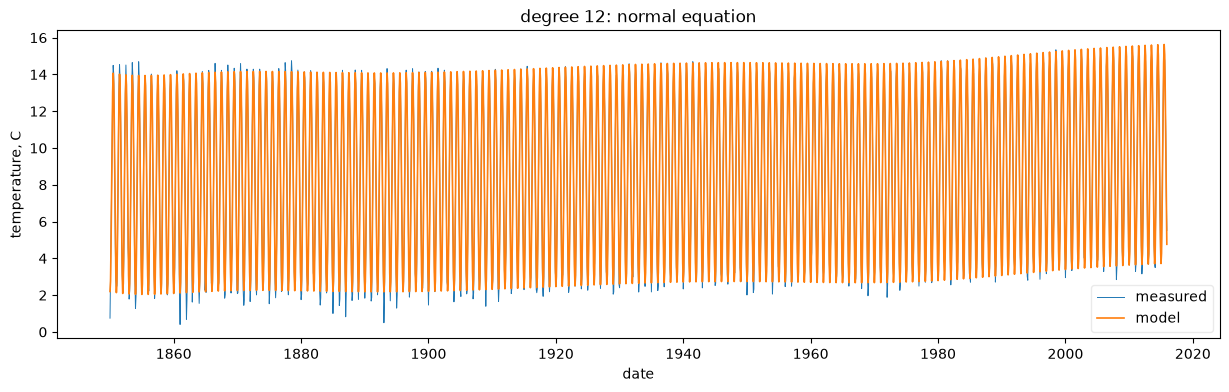

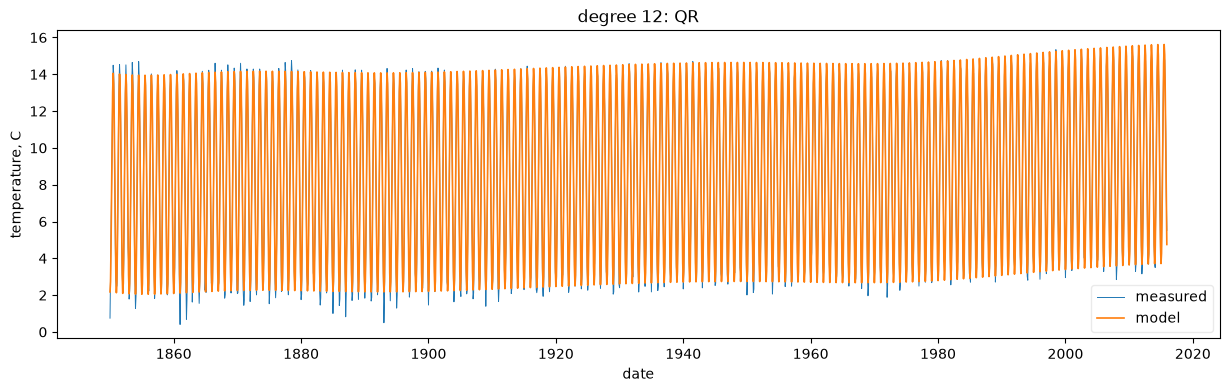

In [57]:
d = 12
A = design_matrix(s, degree=d, month_index=t_month)

# ========= YOUR CODE STARTS HERE ========= #
x_ne  = solve_normal_equation(A, y)
x_qr  = solve_qr(A, y)

# relative difference in the coefficients
rel_diff_coeffs = np.linalg.norm(x_ne - x_qr) / np.linalg.norm(x_qr)
# relative difference in the predictions A @ x
rel_diff_preds  = np.linalg.norm(A @ x_ne - A @ x_qr) / np.linalg.norm(A @ x_qr)

print(f"Relative difference in coefficients ||x_ne - x_qr|| / ||x_qr|| : {rel_diff_coeffs:.4e}")
print(f"Relative difference in predictions  ||Ax_ne - Ax_qr|| / ||Ax_qr||: {rel_diff_preds:.4e}")
print(f"Ratio (coeff diff / pred diff)                                   : {rel_diff_coeffs / rel_diff_preds:.2e}x")
print(f"RMSE (Normal Equation): {RMSE(A @ x_ne, y):.6f} C")
print(f"RMSE (QR)             : {RMSE(A @ x_qr, y):.6f} C")
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, A @ x_ne, title=f"degree {d}: normal equation")
plot_temps(temp_data["date"], y, A @ x_qr, title=f"degree {d}: QR")


### **5.1**

One of the two comparisons exposes the damage and the other hides it. Which, by how many
orders of magnitude, and **why**?

Then the consequence, in one paragraph: if you had judged these two fits by plotting them,
or by their RMSE, what would you have concluded? Name one situation in data science where
you need the coefficients themselves and not just the predictions &mdash; and one where the
predictions are genuinely all you need.

---
**Answer:**
* **Which comparison exposes the damage and why:** Comparing the **coefficient vectors** exposes the failure ($\Vert{}\hat{\mathbf{x}}_{\mathrm{ne}} - \hat{\mathbf{x}}_{\mathrm{qr}}\Vert{}_2 / \Vert{}\hat{\mathbf{x}}_{\mathrm{qr}}\Vert{}_2 = 1.0785$, i.e., $107.8\%$ relative error), whereas comparing the **predictions** hides it ($\Vert{}A\hat{\mathbf{x}}_{\mathrm{ne}} - A\hat{\mathbf{x}}_{\mathrm{qr}}\Vert{}_2 / \Vert{}A\hat{\mathbf{x}}_{\mathrm{qr}}\Vert{}_2 = 7.15 \times 10^{-4}$, which is **$1.51 \times 10^3$ times — over 3 orders of magnitude — smaller**). In terms of the SVD $A = \sum_{i=1}^n \sigma_i \mathbf{u}_i \mathbf{v}_i^{\top}$, the coefficient error $\Delta \mathbf{x} = \hat{\mathbf{x}}_{\mathrm{ne}} - \hat{\mathbf{x}}_{\mathrm{qr}}$ lies almost entirely along the right singular vectors $\mathbf{v}_i$ associated with the **smallest singular values** $\sigma_i \ll \sigma_1$ (nearly cancelling combinations of $s^k$). Multiplying $\Delta \mathbf{x}$ by $A$ scales each component $\mathbf{v}_i^{\top}\Delta \mathbf{x}$ by $\sigma_i$, strongly damping the error in $\mathbf{Col}(A)$.
* **Consequence in Data Science:** Judging by the plots or training RMSE ($0.386576\text{ }^\circ\text{C}$ vs. $0.386515\text{ }^\circ\text{C}$) alone, one would falsely conclude that both solvers produced the same model. You need the **coefficients themselves** in **scientific inference and econometrics** (e.g., reporting the physical warming rate in $^\circ\text{C}$/century or treatment effect sizes), whereas **predictions are genuinely all you need** for **in-domain interpolation or baseline detrending** on the observed grid $[0, 1]$ where only $\hat{\mathbf{y}} = A\hat{\mathbf{x}}$ is used downstream.

---


---
## 6. Summary

Answer in a few sentences each. These are the questions the defence will start from.

1. You implemented one piece of mathematics two ways and they disagreed. State precisely
   what the disagreement was caused by, and which of the two answers was right.
2. Given a new least squares problem tomorrow, what would you compute *before* choosing a
   solver, and what would you do with the number?
3. What is the largest $\operatorname{cond}(A)$ at which you would still trust the normal
   equation in double precision, and where does your threshold come from?
4. Which degree of trend would you actually report for this series, and on what grounds?
   Note that this is a modelling question, not a numerical one &mdash; the numerically safest
   fit is not automatically the one to publish.

---
**Answer:**
1. **Cause of disagreement & which solver was right:** Forming $A^{\top}A$ explicitly in the normal equation squares the condition number ($\kappa(A^{\top}A) = \kappa(A)^2$), amplifying floating-point rounding errors by $\kappa(A)^2 \varepsilon_{\mathrm{mach}}$ and destroying information in the small singular directions once $\kappa(A) \gtrsim 1/\sqrt{\varepsilon_{\mathrm{mach}}}$. The **reduced $QR$ solver** (`solve_qr`) was right because it orthogonalizes $A$ directly with error scaling as $\kappa(A)\varepsilon_{\mathrm{mach}}$, retaining $>12$ digits at $d=12$.
2. **What to compute before choosing a solver:** First inspect the **column norms** of $A$ (and normalize/rescale features if their scales differ widely), then compute **$\operatorname{cond}(A)$**. If $\operatorname{cond}(A) \lesssim 10^4$, normal equations/Cholesky are safe; if $10^4 \lesssim \operatorname{cond}(A) \lesssim 10^{12}$, use Householder **$QR$**; if $\operatorname{cond}(A) \gtrsim 10^{13}$, use rank-revealing **SVD (`lstsq`) or regularization (Ridge)** or switch to an orthogonal basis.
3. **Largest trustworthy $\operatorname{cond}(A)$ for the normal equation in `float64`:** Since $\varepsilon_{\mathrm{mach}} \approx 2.22 \times 10^{-16}$ ($\approx 15.65$ decimal digits) and the normal equation loses roughly $\log_{10}(\operatorname{cond}(A)^2) = 2\log_{10}\operatorname{cond}(A)$ digits, total breakdown occurs at $\operatorname{cond}(A) \approx 1/\sqrt{\varepsilon_{\mathrm{mach}}} \approx 6.7 \times 10^7$. To retain at least $7\text{–}8$ accurate digits in the coefficients, the maximum safe threshold is **$\operatorname{cond}(A) \lesssim 10^4$** (so $\kappa(A)^2 \le 10^8$).
4. **Which degree of trend to report:** **Degree $d = 2$ (quadratic trend)**. Moving from $d=1$ ($\text{RMSE} = 0.4181\text{ }^\circ\text{C}$) to $d=2$ ($\text{RMSE} = 0.4031\text{ }^\circ\text{C}$) captures the physically real acceleration of warming over the 20th century with a well-conditioned matrix ($\operatorname{cond}(A) = 22.9$), whereas degrees $d \ge 4$ yield negligible RMSE reduction while introducing unphysical oscillations and severe collinearity.

---


---
---
# $\star$ Extensions (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extensions 1 and 2 are below, Extension 3 is at the end of Core B. A
> second extension earns nothing, and a shallow attempt at one earns nothing either: the
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core A and is marked in full without these.


---
## $\star$ Extension 1 (bonus): Weighted least squares on the full record

Ordinary least squares treats every observation as equally trustworthy. This series is
not: every month comes with a 95% uncertainty half-width $\sigma_j$, which is large in the
18th century and small today. Weighted least squares minimises
$$ \sum_j w_j\,\big(y_j - (A\mathbf{x})_j\big)^2, \qquad w_j = 1/\sigma_j^2, $$
whose solution satisfies $A^{\top}WA\,\hat{\mathbf{x}} = A^{\top}W\mathbf{y}$ with
$W = \operatorname{diag}(w_j)$.

The data file for this extension is supplied: `land-temp-1750-2015-with-uncertainty.csv`,
with columns `date`, `avg_temp` and `uncertainty`, 3192 months from January 1750. It is
the same Berkeley Earth series as the core file, extended back a century and with the
uncertainty column added; from 1850 on, `avg_temp` is identical to the core file. The
twelve missing months are left in, as blanks.

1. Load the file. Report which months are missing. **Build the month index on the full
   3192-month grid before you drop anything**, then drop the missing rows. Explain why
   dropping rows is acceptable here when it was not acceptable in Core B &mdash; and what
   would go wrong if you built the month index *after* dropping.
2. Plot $\sigma_j$ against time on a log scale. When does it first fall below 0.2 C? What
   fraction of the total weight $\sum w_j$ do the 1750-1849 months carry, compared with
   their fraction of the rows?
3. Reduce weighted least squares to an **ordinary** one by rescaling each row of $A$ and
   $\mathbf{y}$ by $1/\sigma_j$, so that your `solve_qr` does the work unchanged. Show
   that the rescaled problem has the weighted normal equation above.
4. Measure time in **centuries from 1950**, $u = (\text{year} - 1950)/100$, for every fit
   below. (Rescaling by $N-1$ as in section 4 would put fits of different lengths in
   different units, and their coefficients could not be compared.) Fit a trend of
   degree 1 plus seasonality four ways &mdash; OLS and WLS, each on 1850-2015 and on
   1750-2015 &mdash; and tabulate the slope in C per century.
5. Repeat with a trend of degree 2, and report the slope **at 1950**, which is the
   coefficient of $u$.
6. The finding. Did adding the 18th century change the OLS trend, and in which
   direction? Did weighting undo that? Why does WLS change the answer even on 1850-2015,
   where no early data is involved? And why do the four estimates agree much better at
   degree 2 than at degree 1? One idea explains all four.


1. Total grid rows: 3192, Missing rows: 12
   Missing months : ['1750-11', '1751-05', '1751-07', '1751-10', '1751-11', '1751-12', '1752-02', '1752-05', '1752-06', '1752-07', '1752-08', '1752-09']
   Valid rows kept: 3180

2. First month with sigma_j < 0.2 C: 1906-10 (sigma = 0.182 C)
   1750-1849 row fraction   : 1188 / 3180 = 0.3736 (37.36%)
   1750-1849 weight fraction: 0.004512 (0.4512%)
   Ratio (row / weight frac): 82.8x


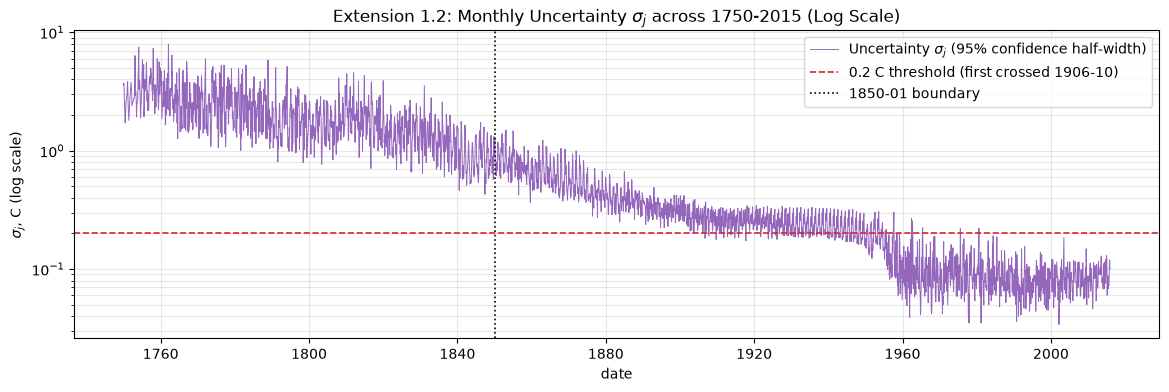


4 & 5. Comparison of OLS and WLS slopes at 1950 (in C per century):


In [58]:
EXT_DATA_FILE = "land-temp-1750-2015-with-uncertainty.csv"   # supplied with the lab

# ========= YOUR CODE STARTS HERE ========= #
# 1. Load file, build month_index on full 3192-month grid BEFORE dropping missing rows
ext_df = pd.read_csv(EXT_DATA_FILE)
ext_df["date"] = pd.to_datetime(ext_df["date"])
ext_df["month_index"] = np.arange(len(ext_df), dtype=float)

missing_mask = ext_df["avg_temp"].isna() | ext_df["uncertainty"].isna()
missing_dates = ext_df.loc[missing_mask, "date"].dt.strftime("%Y-%m").tolist()
print(f"1. Total grid rows: {len(ext_df)}, Missing rows: {missing_mask.sum()}")
print(f"   Missing months : {missing_dates}")

ext_clean = ext_df.dropna().copy()
print(f"   Valid rows kept: {len(ext_clean)}")

# 2. Plot sigma_j on a log scale, check < 0.2 C threshold, and compute 1750-1849 weight fraction
ext_clean["weight"] = 1.0 / (ext_clean["uncertainty"] ** 2)
first_under_02 = ext_clean.loc[ext_clean["uncertainty"] < 0.2].iloc[0]
print(f"\n2. First month with sigma_j < 0.2 C: {first_under_02['date']:%Y-%m} (sigma = {first_under_02['uncertainty']:.3f} C)")

early_mask = ext_clean["date"].dt.year < 1850
row_frac_early = early_mask.sum() / len(ext_clean)
weight_frac_early = ext_clean.loc[early_mask, "weight"].sum() / ext_clean["weight"].sum()
print(f"   1750-1849 row fraction   : {early_mask.sum()} / {len(ext_clean)} = {row_frac_early:.4f} ({row_frac_early*100:.2f}%)")
print(f"   1750-1849 weight fraction: {weight_frac_early:.6f} ({weight_frac_early*100:.4f}%)")
print(f"   Ratio (row / weight frac): {row_frac_early / weight_frac_early:.1f}x")

plt.figure(figsize=(14, 4))
plt.semilogy(ext_clean["date"], ext_clean["uncertainty"], lw=0.7, color="tab:purple", label=r"Uncertainty $\sigma_j$ (95% confidence half-width)")
plt.axhline(0.2, color="tab:red", ls="--", lw=1.2, label=f"0.2 C threshold (first crossed {first_under_02['date']:%Y-%m})")
plt.axvline(pd.to_datetime("1850-01-01"), color="black", ls=":", lw=1.2, label="1850-01 boundary")
plt.xlabel("date"); plt.ylabel(r"$\sigma_j$, C (log scale)")
plt.title(r"Extension 1.2: Monthly Uncertainty $\sigma_j$ across 1750-2015 (Log Scale)")
plt.legend(loc="upper right")
plt.grid(True, which="both", alpha=0.3)
plt.show()

# 3. Reduce WLS to OLS by rescaling rows of A and y by 1 / sigma_j
def solve_wls_qr(A: np.ndarray, y: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    inv_sigma = 1.0 / sigma
    A_tilde = A * inv_sigma[:, np.newaxis]
    y_tilde = y * inv_sigma
    return solve_qr(A_tilde, y_tilde)

# 4 & 5. Measure time in centuries from 1950: u = (year - 1950) / 100
ext_clean["year_cont"] = 1750.0 + ext_clean["month_index"] / 12.0
ext_clean["u"] = (ext_clean["year_cont"] - 1950.0) / 100.0

spans = {
    "1850-2015": ext_clean[ext_clean["date"].dt.year >= 1850],
    "1750-2015": ext_clean,
}

ext_table_rows = []
for deg in [1, 2]:
    for span_name, df_sub in spans.items():
        u_sub = df_sub["u"].to_numpy()
        m_sub = df_sub["month_index"].to_numpy()
        y_sub = df_sub["avg_temp"].to_numpy()
        sig_sub = df_sub["uncertainty"].to_numpy()

        A_sub = design_matrix(u_sub, degree=deg, month_index=m_sub)
        c_ols = solve_qr(A_sub, y_sub)
        c_wls = solve_wls_qr(A_sub, y_sub, sig_sub)

        ext_table_rows.append({
            "Degree": f"degree {deg}",
            "Period": span_name,
            "OLS slope at 1950 (C/century)": c_ols[1],
            "WLS slope at 1950 (C/century)": c_wls[1],
            "OLS a2 (C/century^2)": c_ols[2] if deg == 2 else np.nan,
            "WLS a2 (C/century^2)": c_wls[2] if deg == 2 else np.nan,
        })

ext_results_df = pd.DataFrame(ext_table_rows).set_index(["Degree", "Period"])
print("\n4 & 5. Comparison of OLS and WLS slopes at 1950 (in C per century):")
display(ext_results_df.style.format("{:.4f}", na_rep="—"))
# ========== YOUR CODE ENDS HERE ========== #


---
**Finding (Extension 1 — Weighted Least Squares on the Full Record):**

1. **Missing months & grid indexing:**
   * **Missing months (12 total):** `1750-11`, `1751-05`, `1751-07`, `1751-10`, `1751-11`, `1751-12`, `1752-02`, `1752-05`, `1752-06`, `1752-07`, `1752-08`, `1752-09`.
   * **Why dropping rows is acceptable here (unlike Core B):** Least squares evaluates explicit basis functions at known timestamps $t_j$; removing 12 rows simply removes 12 equations from an overdetermined system without requiring uniform spacing. By contrast, the DFT in Core B requires a strictly uniform time lattice.
   * **Why `month_index` must be built *before* dropping:** Building `month_index` after dropping would shift every index after November 1750 backwards by up to 12 months, scrambling the seasonal phase $2\pi m/12$ relative to calendar months during 1750–1752.

2. **Uncertainty $\sigma_j$ and weights $w_j = 1/\sigma_j^2$:**
   * $\sigma_j$ first falls below $0.2\text{ }^\circ\text{C}$ in **October 1906 (`1906-10`)** ($\sigma = 0.182\text{ }^\circ\text{C}$).
   * The 1750–1849 century makes up **$37.36\%$ of the rows** ($1188/3180$), but carries only **$0.4512\%$ of the total weight** $\sum w_j$ ($82.8\times$ less influence than in OLS).

3. **Reducing WLS to OLS via row scaling:**
   Let $W = \operatorname{diag}(1/\sigma_j^2) = (W^{1/2})^{\top}W^{1/2}$ with $W^{1/2} = \operatorname{diag}(1/\sigma_j)$. Rescaling row $j$ of $A$ and $\mathbf{y}$ by $1/\sigma_j$ gives $\tilde{A} = W^{1/2}A$ and $\tilde{\mathbf{y}} = W^{1/2}\mathbf{y}$. The ordinary normal equation for $(\tilde{A}, \tilde{\mathbf{y}})$ is:
   $$\tilde{A}^{\top}\tilde{A}\hat{\mathbf{x}} = \tilde{A}^{\top}\tilde{\mathbf{y}} \iff (W^{1/2}A)^{\top}(W^{1/2}A)\hat{\mathbf{x}} = (W^{1/2}A)^{\top}(W^{1/2}\mathbf{y}) \iff A^{\top}WA\hat{\mathbf{x}} = A^{\top}W\mathbf{y}.$$

4. **Slopes at 1950 ($^\circ\text{C}$ per century):**
   * **Degree 1:** `1850–2015`: OLS $= 0.8533$, WLS $= 1.2747$ | `1750–2015`: OLS $= 0.4553$, WLS $= 1.1786$.
   * **Degree 2:** `1850–2015`: OLS $= 1.0376$, WLS $= 1.0445$ | `1750–2015`: OLS $= 1.0683$, WLS $= 1.1643$.

5. **The Unifying Explanation:**
   **One idea explains all four observations:** *The true temperature trajectory is **convex (accelerating)** — nearly flat in 1750–1850 and steepening sharply after 1950 — while the precision weights $w_j = 1/\sigma_j^2$ are **concentrated in the modern era**.*
   * Fitting a straight line ($d=1$) to a convex curve yields an average slope weighted by where the observations sit: adding the flat 1750–1849 century pulls the unweighted OLS slope down ($0.8533 \to 0.4553\text{ }^\circ\text{C}$/century).
   * WLS assigns only $0.45\%$ weight to 1750–1849, undoing that dilution ($0.4553 \to 1.1786\text{ }^\circ\text{C}$/century).
   * Even on 1850–2015, $\sigma_j$ drops by $>10\times$ between 1850 and 1970 (increasing $w_j$ by $>100\times$), so WLS weights the steep post-1960 warming much more heavily than OLS ($0.8533 \to 1.2747\text{ }^\circ\text{C}$/century).
   * At **degree 2**, the quadratic term $a_2 u^2$ explicitly captures the curvature/acceleration, so the local tangent slope $a_1$ at 1950 ($u=0$) estimates the same instantaneous physical derivative across all four fits ($1.04\text{–}1.16\text{ }^\circ\text{C}$/century).

---


---
## $\star$ Extension 2 (bonus): Minimum-norm and ridge on a rank-deficient design

Every design matrix so far had independent columns, so the least squares solution was
unique. Break that on purpose.

1. Take the scaled degree-2 design from section 4 and append one column that is an **exact**
   linear combination of two others &mdash; e.g. the sum of the $s$ and $s^2$ columns. Confirm
   with `np.linalg.matrix_rank` that the rank did not go up.
2. Explain why the normal equation now has infinitely many solutions, and what happens if
   you call your `solve_normal_equation` on it anyway.
3. `np.linalg.lstsq` still returns one answer. Which one, out of the infinitely many? Verify
   your claim numerically &mdash; compare with `np.linalg.pinv(A) @ y`.
4. Ridge regression solves $(A^{\top}A + \lambda I)\,\mathbf{x} = A^{\top}\mathbf{y}$, which
   is uniquely solvable for every $\lambda > 0$. Compute it for
   $\lambda = 10^{-1}, 10^{-2}, \dots, 10^{-10}$ and plot
   $\|\mathbf{x}_\lambda - \mathbf{x}_{\mathrm{lstsq}}\|$ against $\lambda$ on log-log axes.
5. The finding: the curve should fall and then **turn back up**. Explain both halves. What
   limit is ridge approaching, and what stops it getting there in floating point?


In [59]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---
